In [1]:
# CIFAR-10 DATASET

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [9]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 99s 1us/step


In [11]:
# Step 3: DATA INSPECTION

print('Train shape:',X_train.shape)
print('Test shape:',X_test.shape)
print('Unique classes:',np.unique(y_train))

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


In [13]:
# Stwp 4: DATA CLEANING - NORMALIZATION
# scale pixel values from 0-255 to 0-1
X_train=X_train/255.0
X_test=X_test/255.0

In [15]:
# Step 5: LABEL ENCODING

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

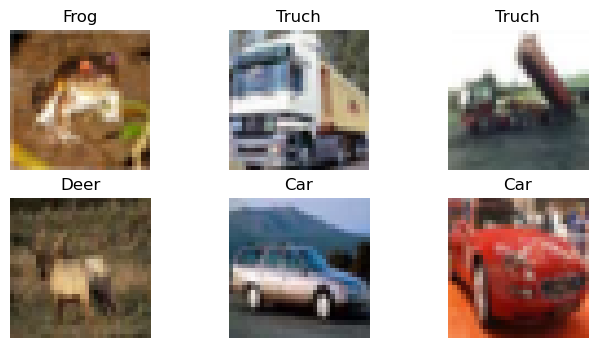

In [19]:
# Step 6: VISUALIZE SAMPLE IMAGES

class_names=['Airplane','Car','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truch']
plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()

In [25]:
# Step 7: BUILD CNN MODEL

model=Sequential()

# convolution block 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Convolution block 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Convolution block 3
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))



In [27]:
# Step 8: FLATTEN & DENSE LAYERS

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10,activation='softmax'))

In [31]:
# Step 9: MODEL SUMMARY
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,586 (627.29 KB)

 Trainable params: 160,394 (626.54 KB)

 Non-trainable params: 192 (768.00 B)

In [35]:
# Step 10: COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    
)

In [37]:
# Step 11: TRAIN MODEL
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 74ms/step - accuracy: 0.4366 - loss: 1.5620 - val_accuracy: 0.4868 - val_loss: 1.5582
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.5837 - loss: 1.1817 - val_accuracy: 0.5894 - val_loss: 1.2668
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.6459 - loss: 1.0115 - val_accuracy: 0.5725 - val_loss: 1.3112
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.6894 - loss: 0.8985 - val_accuracy: 0.5821 - val_loss: 1.2993
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.7208 - loss: 0.8052 - val_accuracy: 0.6702 - val_loss: 0.9646
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.7504 - loss: 0.7252 - val_accuracy: 0.6333 - val_loss: 1.1397
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7694 - loss: 0.6622 - val_accuracy: 0.6865 - val_loss: 0.9119
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7891 - loss: 0.6042 - 

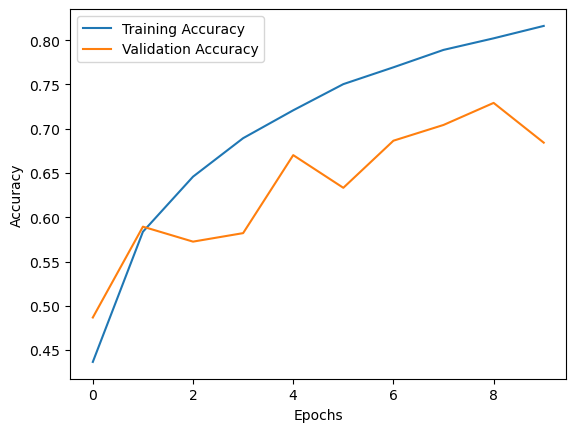

In [41]:
# Step 12: PLOT ACCURACY CURVE
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [47]:
# Step 13: MODEL EVALUATION
loss,accuracy=model.evaluate(X_test,y_test)
print('Test Accuracy:',accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6876 - loss: 1.0422
Test Accuracy: 0.6876000165939331


In [49]:
# Step 14: SINGLE IMAGE PREDICTION

sample=X_test[5].reshape(1,32,32,3)
prediction=model.predict(sample)
print('Predicted Class:',class_names[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
Predicted Class: Frog


(-0.5, 31.5, 31.5, -0.5)

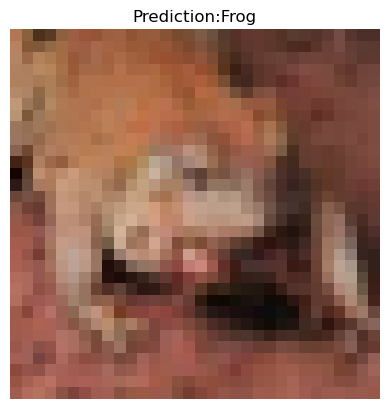

In [55]:
# Step 15: DISPLAY PREDICTION
plt.imshow(X_test[5])
plt.title('Prediction:'+ class_names[np.argmax(prediction)])
plt.axis('off')